# **Практическая работа №12.1. Работа с векторными данными в GeoPandas**

Выполняя практическую работу, опирайтесь на теоритический материал, рассматриваемый на занятии:

- Использование NumPy, Pandas и GeoPandas для работы с пространственными данными: https://u.to/rk86Ig
- Ультимативный обзор аналитических инструментов GeoPandas:  https://u.to/s0d3Ig
- Теоретические аспекты и практические примеры получения векторных данных из OpenStreetMap: https://u.to/9SdwIQ

Дополнительно:

- Особенности построения интерактивных карт с помощью библиотеки Leafmap: https://u.to/WvA3Ig

Официальная техническая документацию по используемым библиотекам:

- **NumPy**: https://numpy.org/doc/stable/
- **Pandas**: https://pandas.pydata.org/docs/
- **GeoPandas**: https://geopandas.org/en/stable/docs.html
- **Leafmap**: https://leafmap.org/

In [2]:
%%capture
!pip install geopandas leafmap mapclassify # Устанавливаем библиотеку GeoPandas и необходимые зависимости

## **Задание №1. Операции с массивами NumPy и геопространственными координатами**


1. Создайте двумерный массив NumPy, содержащий широту и долготу следующих городов: Токио (35.6895, 139.6917), Нью-Йорк (40.7128, -74.0060), Лондон (51.5074, -0.1278) и Париж (48.8566, 2.3522).


In [3]:
import numpy as np
coords = np.array([
    [35.6895, 139.6917],  # Токио
    [40.7128, -74.0060],  # Нью-Йорк
    [51.5074, -0.1278],   # Лондон
    [48.8566, 2.3522]     # Париж
])

2. Преобразуйте значения широты и долготы из градусов в радианы с помощью функции np.radians().


In [4]:
# Ваш код
for ind, i in enumerate(coords):
  coords[ind] = np.radians(i)
print(coords)

[[ 6.22899283e-01  2.43808010e+00]
 [ 7.10572408e-01 -1.29164837e+00]
 [ 8.98973719e-01 -2.23053078e-03]
 [ 8.52708531e-01  4.10536347e-02]]




3. Рассчитайте поэлементную разницу между координатами Токио и других городов в радианах.

In [5]:
# Ваш код
for ind, i in enumerate(coords):
  if ind != 0:
    print(f'{ind}: {i - coords[0]}')

1: [ 0.08767312 -3.72972847] 
2: [ 0.27607444 -2.44031063] 
3: [ 0.22980925 -2.39702647] 


## **Задание 2. Операции с DataFrame Pandas и геопространственными данными**


1. Загрузите набор данных о городах мира по следующему URL с помощью Pandas: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [6]:
import pandas as pd
# Pandas поддерживает загрузку данных по прямым ссылкам из сети Интернет
url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"

df = pd.read_csv(url)

2. Отобразите первые 5 строк и проверьте наличие отсутствующих значений.


In [7]:
# Ваш код
df.head()

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1249 non-null   int64  
 1   name        1249 non-null   object 
 2   country     1249 non-null   object 
 3   latitude    1249 non-null   float64
 4   longitude   1249 non-null   float64
 5   population  1249 non-null   int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 58.7+ KB


3. Отфильтруйте набор данных, чтобы включить только города с населением более 1 миллиона человек.


In [10]:
# Ваш код
df = df[df['population'] > 1000000]
df.head()

,id,name,country,latitude,longitude,population
97,98,Turin,ITA,45.07039,7.66996,1652000
103,104,Lille,FRA,50.64997,3.08001,1044000
123,124,San Bernardino,USA,34.12038,-117.30003,1745000
124,125,Bridgeport,USA,41.17998,-73.19996,1018000
126,127,Manchester,GBR,53.50042,-2.24799,2230000


4. Сгруппируйте города по странам и рассчитайте общую численность населения для каждой страны.


In [11]:
# Ваш код
df.groupby('country')['population'].sum()

,population
country,
AFG,3277000
AGO,6272900
ARE,1379000
ARG,15450000
ARM,1102000
...,...
VNM,11661000
YEM,2008000
ZAF,11738000




5. Отсортируйте города по населению в порядке убывания и отобразите первые 10 городов.

In [12]:
# Ваш код
df.sort_values('population', ascending=False).head(10)

,id,name,country,latitude,longitude,population
1239,1240,Tokyo,JPN,35.68502,139.75141,35676000
1224,1225,New York,USA,40.74998,-73.98002,19040000
1230,1231,Mexico City,MEX,19.44244,-99.13099,19028000
1240,1241,Mumbai,IND,19.01699,72.85699,18978000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1148,1149,Delhi,IND,28.66999,77.23000,15926000
1238,1239,Shanghai,CHN,31.21645,121.43650,14987000
1243,1244,Kolkata,IND,22.49497,88.32468,14787000
1175,1176,Dhaka,BGD,23.72306,90.40858,12797394
1217,1218,Buenos Aires,ARG,-34.60250,-58.39753,12795000


## **Задание №3. Создание и обработка GeoDataFrames с помощью GeoPandas**


1. Загрузите набор данных о зданиях Нью-Йорка из файла GeoJSON с помощью GeoPandas: https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson

In [14]:
# Ваш код
import geopandas as gpd

url = "https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson"
gdf = gpd.read_file(url)

gdf

,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
0,2,15.05,23.30,19.18,6365.72,36,New York,"POLYGON ((-74.00129 40.71992, -74.00061 40.719..."
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."
...,...,...,...,...,...,...,...,...
1201,9764,26.54,22.30,24.42,696.24,36,New York,"POLYGON ((-73.97463 40.72411, -73.97467 40.724..."
1202,9765,10.44,16.53,13.48,2859.96,36,New York,"POLYGON ((-73.98495 40.71911, -73.98436 40.718..."
1203,9766,10.44,13.87,12.16,2859.96,36,New York,"POLYGON ((-73.98495 40.71911, -73.98436 40.718..."
1204,9774,13.76,NaN,13.76,1612.84,36,New York,"POLYGON ((-73.99154 40.71045, -73.99173 40.710..."


2. Создайте график контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


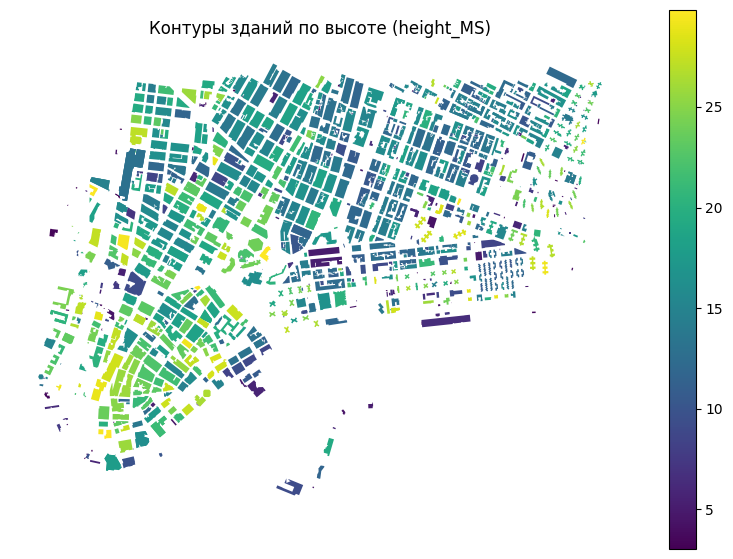

In [27]:
# Ваш код
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
gdf.plot(column='height_MS', ax=ax, cmap='viridis', legend=True)

ax.set_title('Контуры зданий по высоте (height_MS)')
ax.set_axis_off()
plt.show()

3. Создайте интерактивную карту контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


In [40]:
# Ваш код
import leafmap

map = leafmap.Map(zoom=14, center=(40.7128, -74.0060), basemap='CartoDB.Positron')

map.add_data(
    gdf,
    column="height_MS",
    cmap="Blues",
    scheme="EqualInterval",
    legend_title="Высота зданий в метрах",
    layer_name="Высоты зданий",
)

map

Map(center=[40.7128, -74.006], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…

4. Рассчитайте среднюю высоту зданий (используйте столбец `height_MS`).


In [28]:
# Ваш код
gdf['height_MS'].mean()

np.float64(15.454691136974038)

5. Выберите здания с высотой, превышающей среднюю высоту.


In [30]:
# Ваш код
gdf_height = gdf[gdf['height_MS'] > gdf['height_MS'].mean()]
gdf_height

,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."
5,38,18.84,NaN,18.84,1151.88,36,New York,"POLYGON ((-74.01574 40.70672, -74.01537 40.706..."
...,...,...,...,...,...,...,...,...
1196,9714,19.90,19.15,19.52,1230.57,36,New York,"POLYGON ((-73.98328 40.71861, -73.9826 40.7184..."
1198,9752,19.35,NaN,19.35,4080.25,36,New York,"POLYGON ((-73.99528 40.70245, -73.99568 40.702..."
1199,9754,24.11,47.47,35.79,7137.13,36,New York,"POLYGON ((-74.00084 40.71547, -74.00075 40.715..."
1200,9756,16.20,15.17,15.68,166.41,36,New York,"POLYGON ((-73.99054 40.71271, -73.99045 40.712..."





6. Сохраните GeoDataFrame в новый файл GeoJSON.

In [31]:
# Ваш код
gdf.to_file('gdf.geojson', driver='GeoJSON')
gdf_height.to_file('gdf_height.geojson', driver='GeoJSON')

## **Задание №4. Применение NumPy, Pandas и GeoPandas для обработки и анализа пространственных данных**


1. Используйте Pandas для загрузки набора данных о городах мира по следующему URL: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [56]:
# Ваш код

url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
df2 = pd.read_csv(url, encoding='utf-8')

In [57]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1249 non-null   int64  
 1   name        1249 non-null   object 
 2   country     1249 non-null   object 
 3   latitude    1249 non-null   float64
 4   longitude   1249 non-null   float64
 5   population  1249 non-null   int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 58.7+ KB


2. Отфильтруйте набор данных, чтобы включить только города с широтой между -40 и 60 (т.е. города, расположенные в Северном полушарии или вблизи экватора).


In [59]:
# Ваш код
df2 = df2[(df2['latitude'] >= -40) & (df2['latitude'] <= 60)]
df2

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.58330,32.53330,75000
1,2,Fort Portal,UGA,0.67100,30.27500,42670
2,3,Potenza,ITA,40.64200,15.79900,69060
3,4,Campobasso,ITA,41.56300,14.65600,50762
4,5,Aosta,ITA,45.73700,7.31500,34062
...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000
1247,1248,Singapore,SGP,1.29303,103.85582,5183700


3. Создайте GeoDataFrame из отфильтрованного набора данных, преобразовав широту и долготу в геометрии.


In [83]:
# Ваш код
gdf2 = gpd.GeoDataFrame(df2, geometry=gpd.points_from_xy(df2['longitude'], df2['latitude']), crs="EPSG:4326")
gdf2

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.58330,32.53330,75000,POINT (32.5333 0.5833)
1,2,Fort Portal,UGA,0.67100,30.27500,42670,POINT (30.275 0.671)
2,3,Potenza,ITA,40.64200,15.79900,69060,POINT (15.799 40.642)
3,4,Campobasso,ITA,41.56300,14.65600,50762,POINT (14.656 41.563)
4,5,Aosta,ITA,45.73700,7.31500,34062,POINT (7.315 45.737)
...,...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000,POINT (-43.22502 -22.92502)
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000,POINT (-46.62502 -23.55868)
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000,POINT (151.18518 -33.92001)
1247,1248,Singapore,SGP,1.29303,103.85582,5183700,POINT (103.85582 1.29303)


4. Перепроецируйте GeoDataFrame в проекцию Меркатора (EPSG:3857).


In [84]:
# Ваш код
gdf2 = gdf2.to_crs("EPSG:3857")
gdf2

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.58330,32.53330,75000,POINT (3621590.39 64933.781)
1,2,Fort Portal,UGA,0.67100,30.27500,42670,POINT (3370197.584 74697.086)
2,3,Potenza,ITA,40.64200,15.79900,69060,POINT (1758736.635 4959679.293)
3,4,Campobasso,ITA,41.56300,14.65600,50762,POINT (1631498.457 5095742.084)
4,5,Aosta,ITA,45.73700,7.31500,34062,POINT (814302.075 5738302.989)
...,...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000,POINT (-4811787.216 -2622953.59)
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000,POINT (-5190273.485 -2699722.817)
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000,POINT (16829857.253 -4018066.374)
1247,1248,Singapore,SGP,1.29303,103.85582,5183700,POINT (11561176.998 143951.661)


5. Рассчитайте расстояние (в метрах) между каждым городом и Парижем.


In [85]:
# Ваш код
paris = gdf2.loc[gdf2['name'] == 'Paris', 'geometry'].iloc[0]

gdf2['distance_to_paris_m'] = gdf2['geometry'].distance(paris)
gdf2

,id,name,country,latitude,longitude,population,geometry,distance_to_paris_m
0,1,Bombo,UGA,0.58330,32.53330,75000,POINT (3621590.39 64933.781),7.041672e+06
1,2,Fort Portal,UGA,0.67100,30.27500,42670,POINT (3370197.584 74697.086),6.916454e+06
2,3,Potenza,ITA,40.64200,15.79900,69060,POINT (1758736.635 4959679.293),1.979335e+06
3,4,Campobasso,ITA,41.56300,14.65600,50762,POINT (1631498.457 5095742.084),1.794231e+06
4,5,Aosta,ITA,45.73700,7.31500,34062,POINT (814302.075 5738302.989),7.561058e+05
...,...,...,...,...,...,...,...,...
1244,1245,Rio de Janeiro,BRA,-22.92502,-43.22502,11748000,POINT (-4811787.216 -2622953.59),1.022204e+07
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000,POINT (-5190273.485 -2699722.817),1.048050e+07
1246,1247,Sydney,AUS,-33.92001,151.18518,4630000,POINT (16829857.253 -4018066.374),1.949483e+07
1247,1248,Singapore,SGP,1.29303,103.85582,5183700,POINT (11561176.998 143951.661),1.284655e+07




6. Отобразите города на карте мира, раскрасив точки в зависимости от их расстояния до Парижа.



> 💡 **Подсказка:** Вы можете использовать интерактивную карту `leafmap.Map()` и метод m.add_data(), передав в него ваш GeoDataFrame (предварительно возвращенный в систему координат EPSG:4326).

Основные параметры данного метода:


* column — столбец с рассчитанным расстоянием до Парижа (предварительно разделите значение расстояния на 1000, чтобы легенда отображалась в километрах).
* cmap — цветовая палитра (например, "plasma", "viridis" или "YlOrRd").
* k — количество цветовых интервалов (рекомендуется 10–15 для плавности).
* scheme — алгоритм классификации данных:
  * "Quantiles" (Квантили) — делит города на группы с равным количеством точек в каждой. Это создаст максимальный цветовой контраст: даже если города расположены кучно, вы увидите разницу между ними.
   * "EqualInterval" (Равные интервалы) — делит весь диапазон расстояний на равные отрезки в километрах (например, 0-1000 км, 1000-2000 км и т.д.). Это нагляднее показывает реальный масштаб удаленности.



* установите параметр add_legend=True, чтобы на карте появилась шкала соответствия цветов и расстояний.

In [86]:
# Ваш код
import leafmap

gdf2 = gdf2.to_crs("EPSG:4326")

map = leafmap.Map(zoom=2, basemap='CartoDB.Positron')

map.add_data(
    gdf2,
    column="distance_to_paris_m",
    cmap="plasma",
    k=12,
    scheme="EqualInterval",
    add_legend=True
)

map

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…